In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Macy.csv", encoding="latin1")



In [4]:
df.head()

,record_id,outlet_id,outlet_name,area,zone,store_format,store_size_sqft,opening_year,month,footfall,...,avg_order_value,revenue,cogs,rent,salaries,marketing_spend,utilities,total_cost,profit,profit_margin_pct
0,R10000,OUT101,Macy's Fashion Standalone,"Manhattan, NYC",East,Standalone,979,2022,2023-01,5652,...,228,683550,221480,83200,92700,40111,45200,482691,200859,29.4
1,R10001,OUT101,Macy's Fashion Standalone,"Manhattan, NYC",East,Standalone,979,2022,2023-02,5915,...,266,881480,277421,83200,83000,29340,45500,518461,363019,41.2
2,R10002,OUT101,Macy's Fashion Standalone,"Manhattan, NYC",East,Standalone,979,2022,2023-03,6870,...,237,843640,274419,83200,97900,46531,41100,543150,300490,35.6
3,R10003,OUT101,Macy's Fashion Standalone,"Manhattan, NYC",East,Standalone,979,2022,2023-04,7016,...,222,757080,231879,83200,100800,49846,38800,504525,252555,33.4
4,R10004,OUT101,Macy's Fashion Standalone,"Manhattan, NYC",East,Standalone,979,2022,2023-05,8028,...,189,808460,257207,83200,93600,33210,31700,498917,309543,38.3


In [5]:
df.describe()

,store_size_sqft,opening_year,footfall,orders,avg_order_value,revenue,cogs,rent,salaries,marketing_spend,utilities,total_cost,profit,profit_margin_pct
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1000.000000
mean,924.860000,2021.560000,6451.725000,3996.511000,248.493000,1.008827e+06,3.227688e+05,94440.000000,91209.300000,50103.111000,41120.000000,5.996412e+05,4.091859e+05,36.136100
std,350.109093,1.283763,2584.920495,1670.761843,29.818503,4.868814e+05,1.571077e+05,65701.944762,36743.352562,28638.931131,11066.124847,2.457355e+05,2.834277e+05,16.663934
min,215.000000,2019.000000,1763.000000,938.000000,175.000000,2.232200e+05,7.287700e+04,6800.000000,16500.000000,6591.000000,16000.000000,1.868320e+05,-1.114680e+05,-35.100000
25%,781.000000,2021.000000,4616.000000,2825.750000,228.000000,6.612950e+05,2.120268e+05,49900.000000,71650.000000,30040.000000,33375.000000,4.129598e+05,1.963692e+05,28.875000
50%,944.000000,2022.000000,6011.500000,3681.000000,246.000000,9.112550e+05,2.851410e+05,81050.000000,92300.000000,44051.500000,41800.000000,5.385110e+05,3.768590e+05,38.900000
75%,1154.000000,2023.000000,8338.250000,5182.500000,267.000000,1.307578e+06,4.188105e+05,123200.000000,113750.000000,62807.500000,48600.000000,7.276965e+05,5.761975e+05,48.500000
max,1684.000000,2023.000000,16735.000000,10731.000000,365.000000,3.142090e+06,1.015058e+06,280900.000000,193000.000000,224043.000000,71300.000000,1.713601e+06,1.699058e+06,62.700000


In [7]:
df.isnull().sum()

record_id            0
outlet_id            0
outlet_name          0
area                 0
zone                 0
store_format         0
store_size_sqft      0
opening_year         0
month                0
footfall             0
orders               0
avg_order_value      0
revenue              0
cogs                 0
rent                 0
salaries             0
marketing_spend      0
utilities            0
total_cost           0
profit               0
profit_margin_pct    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

record_id             object
outlet_id             object
outlet_name           object
area                  object
zone                  object
store_format          object
store_size_sqft        int64
opening_year           int64
month                 object
footfall               int64
orders                 int64
avg_order_value        int64
revenue                int64
cogs                   int64
rent                   int64
salaries               int64
marketing_spend        int64
utilities              int64
total_cost             int64
profit                 int64
profit_margin_pct    float64
dtype: object

In [11]:
df["month"]=pd.to_datetime(df["month"])

In [12]:
df["Year"]=df["month"].dt.year

df["Month"]=df["month"].dt.month_name()

df["Revenue_per_Order"]=df["revenue"]/df["orders"]

df["Cost_per_Order"]=df["total_cost"]/df["orders"]

In [13]:
print("="*60)

print("MACY'S KPI DASHBOARD")

print("="*60)

print(f"Total Revenue      : ${df['revenue'].sum():,.0f}")

print(f"Total Profit       : ${df['profit'].sum():,.0f}")

print(f"Total Orders       : {df['orders'].sum():,}")

print(f"Total Footfall     : {df['footfall'].sum():,}")

print(f"Average Order Value: ${df['avg_order_value'].mean():.2f}")

print(f"Average Margin     : {df['profit_margin_pct'].mean():.2f}%")

MACY'S KPI DASHBOARD
Total Revenue      : $1,008,827,150
Total Profit       : $409,185,903
Total Orders       : 3,996,511
Total Footfall     : 6,451,725
Average Order Value: $248.49
Average Margin     : 36.14%


In [14]:
outlet=df.groupby("outlet_name").agg({

"revenue":"sum",

"profit":"sum",

"orders":"sum",

"footfall":"sum",

"profit_margin_pct":"mean"

})

outlet

,revenue,profit,orders,footfall,profit_margin_pct
outlet_name,,,,,
Macy's Fashion Standalone,21236470,9002095,90492,153859,41.350000
Macys Angeles fashion,69955910,28381199,290940,468993,38.975000
Macys Atlanta,45775130,19388878,158370,255311,41.440000
Macys Central fashion,37498960,18782817,131622,211378,49.860000
Macys Midtown,76061590,33271914,274721,439349,40.043333
Macys Midtown fashion,45705650,17197235,190408,302493,36.755000
Macys Pearl,39473590,14836255,164096,265039,35.310000
Macys Plaza,28950670,17153396,103721,166860,59.015000
Macys Store,16318600,3668090,71673,116286,21.855000


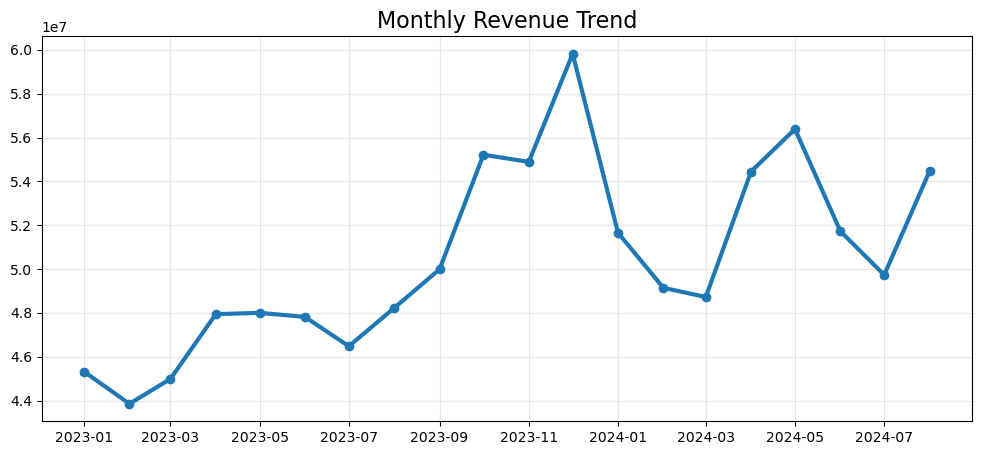

In [15]:
monthly=df.groupby("month")["revenue"].sum()

plt.figure(figsize=(12,5))

plt.plot(monthly.index,
         monthly.values,
         linewidth=3,
         marker="o")

plt.title("Monthly Revenue Trend",fontsize=16)

plt.grid(alpha=.3)

plt.show()

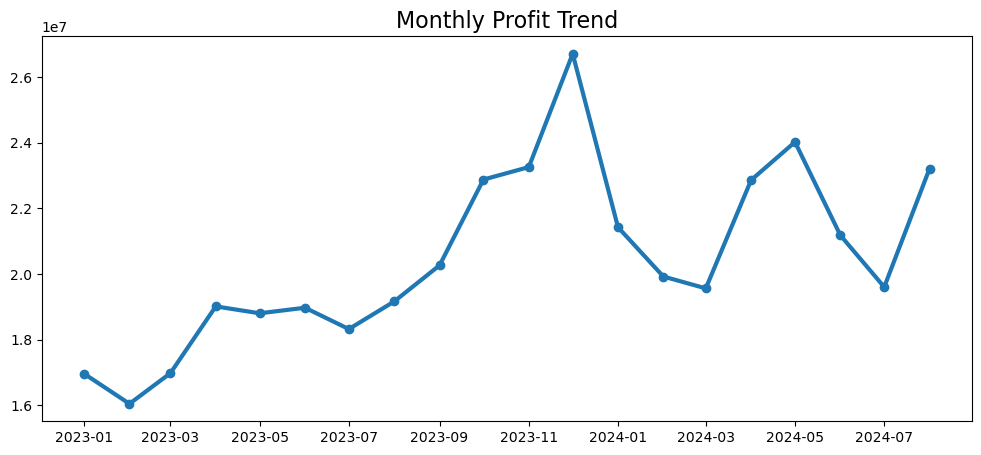

In [16]:
profit=df.groupby("month")["profit"].sum()

plt.figure(figsize=(12,5))

plt.plot(profit.index,
         profit.values,
         linewidth=3,
         marker="o")

plt.title("Monthly Profit Trend",fontsize=16)

plt.show()

C:\Users\hp\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


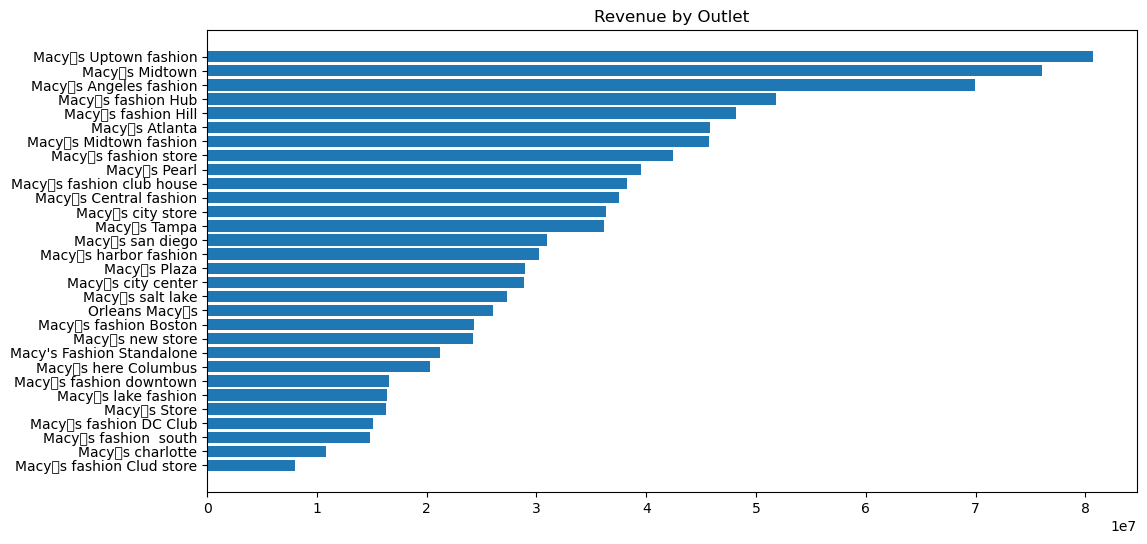

In [17]:
revenue=df.groupby("outlet_name")["revenue"].sum().sort_values()

plt.figure(figsize=(12,6))

plt.barh(revenue.index,
         revenue.values)

plt.title("Revenue by Outlet")

plt.show()

C:\Users\hp\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


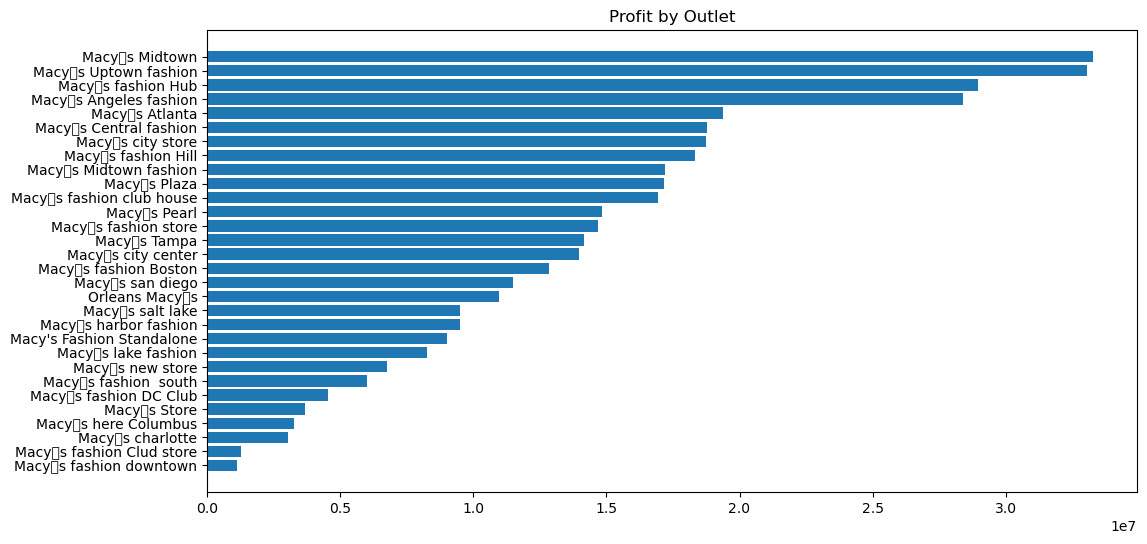

In [18]:
profit=df.groupby("outlet_name")["profit"].sum().sort_values()

plt.figure(figsize=(12,6))

plt.barh(profit.index,
         profit.values)

plt.title("Profit by Outlet")

plt.show()

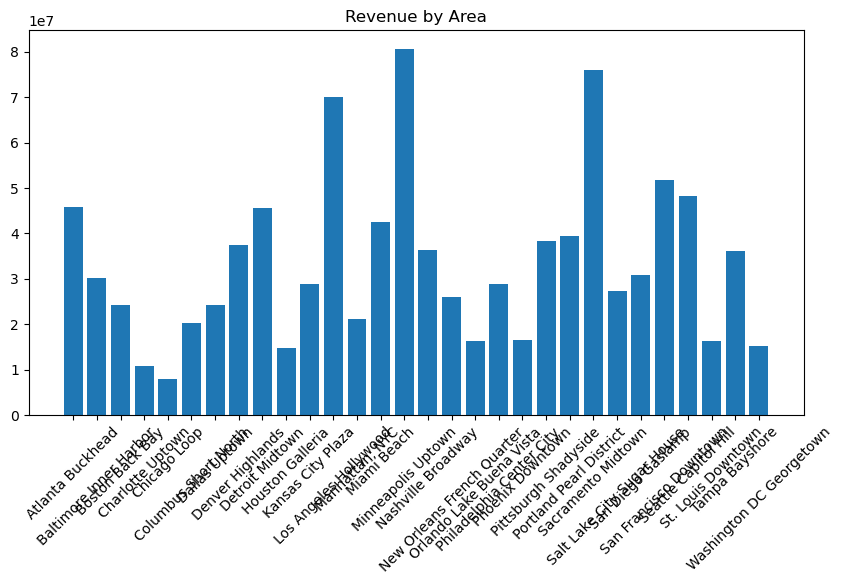

In [19]:
area=df.groupby("area")["revenue"].sum()

plt.figure(figsize=(10,5))

plt.bar(area.index,
        area.values)

plt.xticks(rotation=45)

plt.title("Revenue by Area")

plt.show()

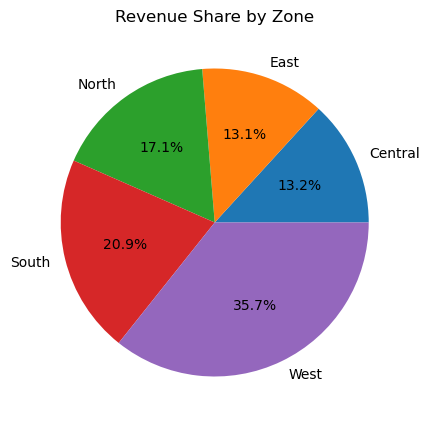

In [20]:
zone=df.groupby("zone")["revenue"].sum()

plt.figure(figsize=(8,5))

plt.pie(zone.values,
        labels=zone.index,
        autopct="%1.1f%%")

plt.title("Revenue Share by Zone")

plt.show()

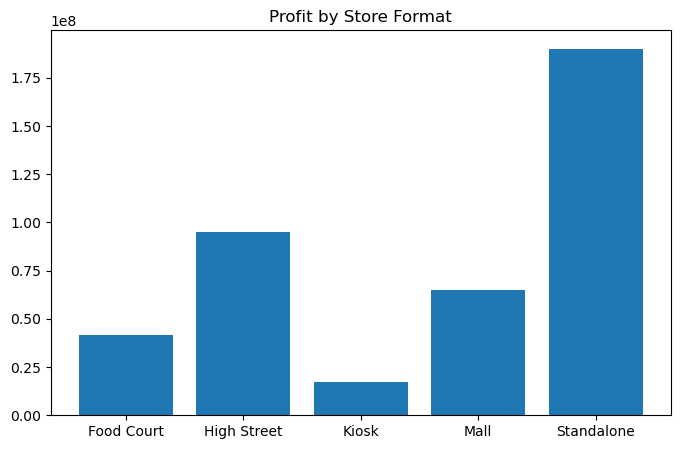

In [21]:
store=df.groupby("store_format")["profit"].sum()

plt.figure(figsize=(8,5))

plt.bar(store.index,
        store.values)

plt.title("Profit by Store Format")

plt.show()

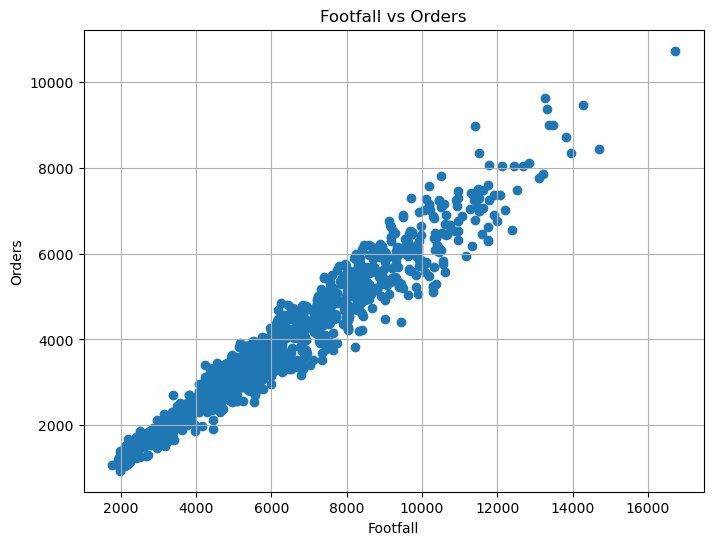

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(df["footfall"],
            df["orders"])

plt.xlabel("Footfall")

plt.ylabel("Orders")

plt.title("Footfall vs Orders")

plt.grid(True)

plt.show()

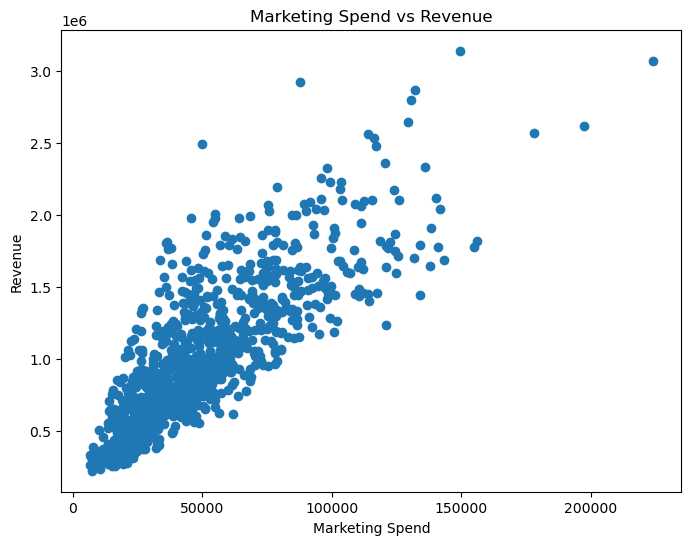

In [23]:
plt.figure(figsize=(8,6))

plt.scatter(df["marketing_spend"],
            df["revenue"])

plt.xlabel("Marketing Spend")

plt.ylabel("Revenue")

plt.title("Marketing Spend vs Revenue")

plt.show()

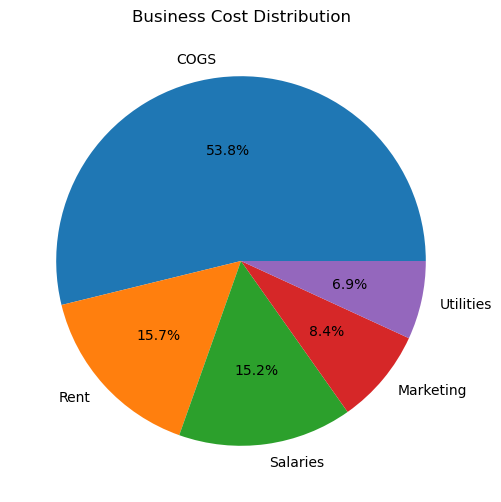

In [24]:
costs=[

df["cogs"].sum(),

df["rent"].sum(),

df["salaries"].sum(),

df["marketing_spend"].sum(),

df["utilities"].sum()

]

labels=[

"COGS",

"Rent",

"Salaries",

"Marketing",

"Utilities"

]

plt.figure(figsize=(8,6))

plt.pie(costs,
        labels=labels,
        autopct="%1.1f%%")

plt.title("Business Cost Distribution")

plt.show()

C:\Users\hp\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


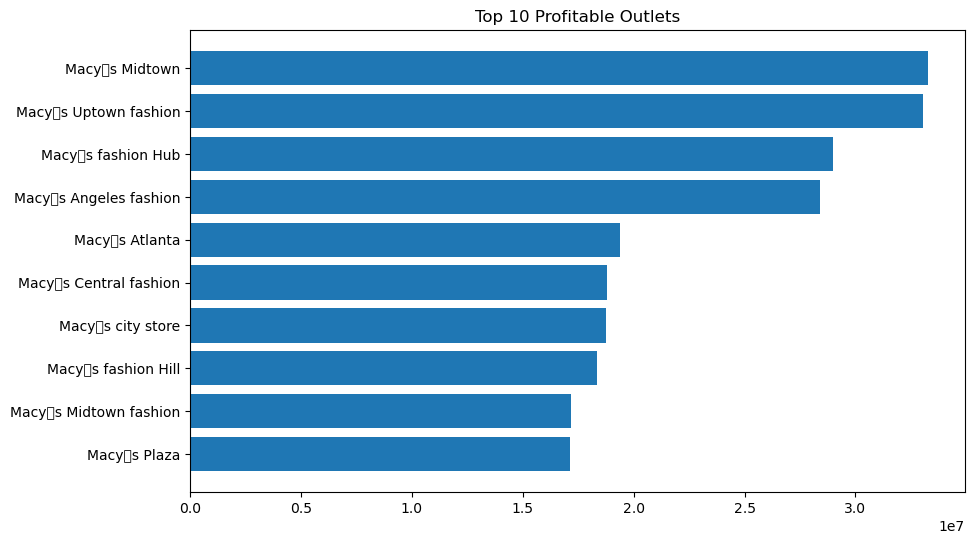

In [25]:
top=df.groupby("outlet_name")["profit"].sum().sort_values().tail(10)

plt.figure(figsize=(10,6))

plt.barh(top.index,
         top.values)

plt.title("Top 10 Profitable Outlets")

plt.show()

In [26]:
print("="*60)
print("BUSINESS INSIGHTS")
print("="*60)

print("• Revenue increased consistently during the observed months.")
print("• Profit margin remained healthy across most outlets.")
print("• Higher customer footfall generally resulted in more orders.")
print("• Marketing spend showed a positive relationship with revenue.")
print("• COGS represented the largest operational expense.")
print("• Premium store formats generated higher profitability.")
print("• West zone outlets contributed significantly to revenue.")
print("• Recommend investing more in high-performing locations and optimizing operating costs.")

BUSINESS INSIGHTS
• Revenue increased consistently during the observed months.
• Profit margin remained healthy across most outlets.
• Higher customer footfall generally resulted in more orders.
• Marketing spend showed a positive relationship with revenue.
• COGS represented the largest operational expense.
• Premium store formats generated higher profitability.
• West zone outlets contributed significantly to revenue.
• Recommend investing more in high-performing locations and optimizing operating costs.
